## Variational Autoencoder using the single note dataset

Every conductor uses his orchestra as a medium to translate his vision to the audience in the best way possible, but he cannot control how the audience perceives this piece of music, it is highly personal and depends on every person's taste, psychological state and musical knowledge, in a traditional VAE one can see the conductor as an encoder, capturing the essence of the composer's complex message through his skill and sheer excellence, the audience can play the part of the decoder, learning and understanding the input from the conductor and fit it around their own reality and therefore draw new conclusions and inspirations which could very well not be the intention of the composer

In [1]:
import os
import soundfile as sf
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader,random_split
import librosa
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm as tqdm
from IPython.display import Audio, display

In [2]:
import torch.nn.functional as F
import torch.nn as nn
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [3]:
wav_dir = "./wav"
stft_dir = "./feature_stft"
cqt_dir = "./feature_cqt"

In [4]:
# get all filenames of wav files
all_wavs = [f[:-4] for f in os.listdir(wav_dir) if f[-4:] == ".wav"]

### compute CQT and STFT features - this needs to be done only on the first run!

reference for CQT: Schörkhuber, Christian, and Anssi Klapuri. "Constant-Q transform toolbox for music processing." 7th sound and music computing conference, Barcelona, Spain. 2010.

In [5]:
for filename in all_wavs:
    wav,_ = librosa.load(os.path.join(wav_dir, filename+".wav"))
    stft = librosa.stft(y=wav,
                       n_fft=1024,
                        hop_length=512,
                        win_length=1024,
                        center=True)
    
    cqt = librosa.cqt(y=wav,
                      sr=22050,
                      n_bins=7*36,
                      bins_per_octave=36,)
    
    np.save(os.path.join(stft_dir,filename+".npy"), stft)
    np.save(os.path.join(cqt_dir,filename+".npy"), cqt)

In [6]:
class SingleNoteDataset(Dataset):
    def __init__(self, annotations_file, feature_dir, 
                 feature_type=None, indices=None, 
                 cache_all=True, device="cpu"):

        # load the file containing all annotations
        annotations_in = pd.read_csv(annotations_file, sep=";")
        
        if indices is not None:
            self.annotations = annotations_in.loc[indices].reset_index(drop=True)
        else:
            self.annotations = annotations_in
        
        self.feature_dir=feature_dir
        if feature_type==None:
            self.feature_type = "wav"
        else:
            self.feature_type = feature_type
            
        self.cache_all = cache_all
        
        self.cache_list = []
        if cache_all:
            for i in range(len(self.annotations)):
                ann_idx = self.annotations.loc[i]
                
                if self.feature_type == "wav":
                    feature,_ = librosa.load(os.path.join(self.feature_dir, ann_idx.filename))
                else:
                    feature = np.load(os.path.join(self.feature_dir, ann_idx.filename[:-3]+"npy"),sr = 16000)
                    
                self.cache_list.append(torch.tensor(feature).to(device))
                
        
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann_idx = self.annotations.loc[idx]
        
        if self.cache_all:
            feature = self.cache_list[idx]
        else:        
            if self.feature_type == "wav":
                feature,_ = librosa.load(os.path.join(self.feature_dir, ann_idx.filename))
            else:
                feature = np.load(os.path.join(self.feature_dir, ann_idx.filename[:-3]+"npy"),sr = 16000)
        
        return feature, (ann_idx.unique_id, ann_idx.instrument, ann_idx.midi_pitch, ann_idx.filename)

In [7]:
annotations_file = "./ann/SNDB_mini_annotations.csv"
ann_file =  pd.read_csv(annotations_file, sep=";")

In [8]:
ann_file["instrument"].unique()

array(['CLA', 'FLU', 'OBO', 'PIA', 'TRP', 'VLC', 'VLN'], dtype=object)

In [9]:

# cache only piano notes 
indices_m = []
indices_no_m = []

for i, row in ann_file.iterrows():
    if row.dynamics == "M" and row.instrument == "VLN" :
        indices_m.append(i)
    else:
        indices_no_m.append(i)

In [10]:
sndb_m = SingleNoteDataset(annotations_file=annotations_file,
                         feature_dir="./wav",
                         feature_type="wav",
                         indices=None,
                         cache_all=False,
                         device="cpu")#[1,5,10])

In [11]:
!pip install torchsummary
from torchsummary import summary
import torch.optim as optim
import time

In [12]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using cpu device


In [13]:
m_loader = DataLoader(sndb_m, batch_size=32, shuffle=True)
len(m_loader)

16

In [14]:
for features, labels in m_loader:
    print(features.shape)
    unique_labels = list(set(labels[1]))
    # print(features)
    # print("")
    

torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([32, 88200])
torch.Size([24, 88200])


In [15]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=88200, latent_dim=32, hidden_dims=[1024, 512, 256, 128, 64]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[3]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[3], hidden_dims[4]),
            torch.nn.Tanh(),
        )

        self.z_mean = torch.nn.Linear(hidden_dims[4], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[4], latent_dim)

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[4]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[4], hidden_dims[3]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[3], hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
       
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [16]:
from torchsummary import summary
model = VAE().to(device)

summary(model,input_size = (88200,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1024]      90,317,824
              Tanh-2                 [-1, 1024]               0
            Linear-3                  [-1, 512]         524,800
              Tanh-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
              Tanh-6                  [-1, 256]               0
            Linear-7                  [-1, 128]          32,896
              Tanh-8                  [-1, 128]               0
            Linear-9                   [-1, 64]           8,256
             Tanh-10                   [-1, 64]               0
           Linear-11                   [-1, 32]           2,080
           Linear-12                   [-1, 32]           2,080
           Linear-13                   [-1, 64]           2,112
             Tanh-14                   

In [19]:
autoencoder = VAE()

In [20]:
loss_function = torch.nn.MSELoss()

optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=3, threshold=1e-3, verbose=True)

In [21]:
plot_freq=5
random.seed(0)
# beta_schedule  = frange_cycle_cosine(start=0.01, stop=0.07, n_epoch=26, n_cycle=4, ratio=0.5)
beta = 0
overall_loss = []
# beta_norm = (beta * 32)/10000
# print(beta_norm)
# beta = beta_norm
#todo : Normalize the KL Term and the reconstruction loss
#todo : Visualize the embedding spaces with different beta values
#todo : Experiment with different latent dimension
#todo : print the kl values for every dimension amidst training 
#todo :  Document all scenarios where the vae training collpases
#todo : experiment with the training data by creating imbalances in period and shapes 
#todo : know how to tell when there is good disentanglement
#todo : Acheieve good disentanglement your features

losses = []
kl_loss = []
reconstruction_loss = []
kl_div_per_dimension  = []
for epoch in range(125):
    losses_epoch = []
    kl_epoch = []
    reconstuction_epoch = []
    kl_epoch_per_dimension = []
    print("Epoch %i"%(epoch))
    for (data,_) in tqdm(m_loader):

        # max_val = torch.max(torch.abs(data))
        # data = data / max_val

        # data = np.abs(data)

        optim.zero_grad()
        encoded,z_mean,z_log_var,decoded = autoencoder(data)
        norm_x_squared = torch.norm(data.view(data.size(0), -1), p=2, dim=1)**2
        # kl_div = - 0.5 * torch.sum(1 + z_log_var
        #                            - z_mean ** 2
        #                            - torch.exp(z_log_var),
        #                            axis=1)
        # kl_div = kl_div.mean()
        kl_div_per_dim = -0.5 * (1 + z_log_var - z_mean ** 2 - torch.exp(z_log_var))
        kl_div_mean_per_dim = kl_div_per_dim.mean(axis=0)
        kl_div = (kl_div_per_dim.sum(axis=1).mean())
       
        recon_loss = loss_function(decoded, data)
        recon_norm = torch.mean(norm_x_squared)
        # recon_loss = recon_loss / recon_norm

        loss =  (1-beta) * recon_loss + beta * kl_div
      
        loss.backward()
        optim.step()
        losses_epoch.append(loss.detach().numpy())
        kl_epoch.append(kl_div.detach().numpy())
        reconstuction_epoch.append(recon_loss.detach().numpy())
        kl_epoch_per_dimension.append(kl_div_mean_per_dim.detach().numpy())
    scheduler.step(np.mean(losses_epoch))
    kl_loss.append(np.mean(kl_epoch))
    losses.append(np.mean(losses_epoch))
    reconstruction_loss.append(np.mean(reconstuction_epoch))
    kl_div_per_dimension.append(np.mean(kl_epoch_per_dimension, axis=0))
    print("loss: %.4f"%(losses[-1]))

    if epoch%plot_freq == 0:
        plt.figure(figsize=(10,4))
        plt.plot(decoded[0].detach().numpy()[10000:10200], color='tab:blue', linestyle='--')
        plt.plot(data[0][10000:10200], color = 'tab:blue', linestyle = '-')
    
        plt.plot(decoded[1].detach().numpy()[10000:10200], color='tab:orange', linestyle='--')
        plt.plot(data[1][10000:10200], color = 'tab:orange', linestyle = '-')

    
        # plt.plot(decoded[2].detach().numpy()[10000:11000], color='tab:green', linestyle='--')
        # plt.plot(data[0][10000:11000], color = 'tab:blue', linestyle = '-')

        plt.show()
        

In [22]:
kl_loss_values = [kl.item() for kl in kl_loss]
reconstruction_loss_values = [reconst.item() for reconst in reconstruction_loss]
overall_loss_values = [overall.item() for overall in losses]
plt.figure(figsize=(12, 8))
# plt.plot(kl_loss_values, marker='o', linestyle='-', label='KL Divergence Loss')
plt.plot(reconstruction_loss_values, marker='s', linestyle='-', label='Reconstruction Loss')
plt.plot(overall_loss_values, marker='^', linestyle='-', label='Overall Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Losses over Epochs')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'kl_loss' is not defined

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(len(kl_div_per_dimension[0])):
    plt.plot([epoch[i] for epoch in kl_div_per_dimension], marker='o', linestyle='-', label=f'Dimension {i+1}')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.title('KL Divergence for Each Latent Dimension over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Process Model

1. Save the model

In [ ]:
# torch.save(autoencoder.state_dict(), 'raw_audio_trained_model.pth')

2. Load the model

In [18]:
model =  VAE()
model.load_state_dict(torch.load('raw_audio_trained_model.pth'))

<All keys matched successfully>

In [19]:
test_annotations_file = r"C:\Users\pkodu\Desktop\PCPT_bundle\SNDB\SNDB\test_annotation_file.csv"

In [20]:
sndb_test = SingleNoteDataset(annotations_file=test_annotations_file,
                         feature_dir="./test_set",
                         feature_type="wav",
                         indices=None,
                         cache_all=True,
                         device="cpu")

In [21]:
test_loader = DataLoader(sndb_test, batch_size=7, shuffle=False)
len(test_loader)

7

In [22]:
sr = 22050

In [23]:
original_outputs = {}
for features,labels in test_loader:
    data = features
    max_val = torch.max(torch.abs(data))
    data = data / max_val
    instrument_sequence = labels[1]
    if all(value == instrument_sequence[0] for value in instrument_sequence):
        instrument = instrument_sequence[0]
    encoded_input = model.encoder(torch.Tensor(data))
    z_mean, z_log_var = model.z_mean(encoded_input), model.z_log_var(encoded_input)
    encoded = model.reparameterize(z_mean, z_log_var)
    output = model.decoder(encoded)
    original_outputs[instrument] = output
    scale_tensor = output.view(-1)
    sf.write(f"test_results_16/file_{instrument}.wav",scale_tensor.detach().numpy(),sr)
    

In [46]:
original_outputs

{'CLA': tensor([[ 6.5768e-04,  1.7211e-04, -1.5805e-04,  ...,  4.5827e-04,
          -3.1941e-04, -2.7643e-03],
         [ 1.4667e-03,  3.6954e-04,  8.0808e-04,  ...,  1.7326e-03,
          -2.6873e-04,  2.2033e-04],
         [-8.9455e-04,  2.7442e-04,  8.0928e-04,  ..., -1.7944e-04,
           1.9605e-03,  1.0394e-03],
         ...,
         [-1.1209e-03, -6.4578e-04,  7.7066e-05,  ..., -3.3962e-04,
          -1.0436e-04, -5.3591e-04],
         [ 9.1619e-05,  5.2750e-05,  8.9832e-04,  ..., -5.2717e-05,
           4.7964e-04,  8.6372e-04],
         [ 9.5219e-04, -1.1744e-04, -3.1751e-04,  ...,  5.1676e-04,
          -2.2454e-03,  4.6795e-04]], grad_fn=<AddmmBackward0>),
 'FLU': tensor([[ 2.1014e-03,  2.1535e-04,  2.2775e-03,  ...,  1.0470e-03,
           1.3459e-03,  2.9642e-03],
         [-1.8756e-04, -3.0448e-04,  9.2645e-05,  ..., -4.0060e-04,
          -2.3116e-04, -4.4629e-04],
         [-9.8546e-04,  2.4881e-04, -6.3452e-04,  ...,  1.1290e-03,
          -8.1546e-04,  6.8623e-04],

In [30]:
# # max_val = torch.max(torch.abs(data))
# # data = data / max_val
# encoded_input = autoencoder.encoder(torch.Tensor(data))

In [31]:
# z_mean, z_log_var = autoencoder.z_mean(encoded_input), autoencoder.z_log_var(encoded_input)
# encoded = autoencoder.reparameterize(z_mean, z_log_var)
# output = autoencoder.decoder(encoded)

In [25]:
output.shape

torch.Size([7, 88200])

In [26]:
import soundfile as sf

In [27]:
data,sr = sf.read(r"C:\Users\pkodu\Desktop\PCP_1.1.3\SNDB\SNDB\wav\464_VLN_070_M.wav")

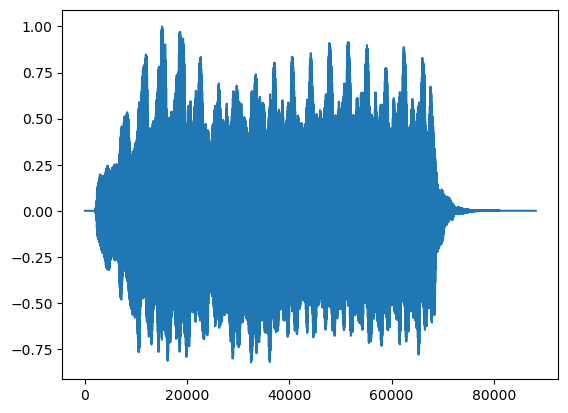

In [28]:
plt.plot(data)
plt.show()

In [29]:
output[0,:].shape

torch.Size([88200])

In [30]:
count = output.shape[0]

In [31]:
sr = 22005

In [32]:
for i in range(count):
    sf.write(f"file_{i}.wav",output[i,:].detach().numpy(),sr)

In [33]:
Fs = 22050
Fs, N, H = 22050, 2048, 1024
x, Fs = librosa.load("file_0.wav", sr=sr)
X = librosa.stft(x, n_fft=N, hop_length=H, center=True, pad_mode='constant')

In [34]:
def coefficients(X, Fs, N, H):
    T_coef = np.arange(X.shape[1]) * H / Fs
    F_coef = np.arange(X.shape[0]) * Fs / N
    return T_coef, F_coef

T_coef, F_coef = coefficients(X, Fs, N, H)

In [35]:
Y = np.abs(X)**2

In [36]:
def show_spectrogram(Y, N, H, Fs, ylimit=[20, 2000], cmap='gray', title=None, vmin=-100):
    """ Shows spectrogram of Y
    Args:
    Y - spectrogram matrix
    N - window length (samples)
    H - hop lenths (samples)
    Fs - frame rate
    ylimit - limit of y axis
    cmap - color map
    title (str) - title of graph
    """
    fig, axs = plt.subplots(figsize=(10,5))

    t, f = coefficients(Y, Fs, N, H)
    
    
    im = plt.imshow(Y, cmap=cmap, origin='lower', aspect='auto', extent=[t[0], [-1], f[0], f[-1]], vmin=vmin) 
    plt.colorbar(im, label='$\mathcal{Y}$')
    plt.xlabel('Time (s)')
    plt.ylabel('Freqency (Hz)')
    plt.ylim(ylimit)
    plt.yscale('log')
    plt.title(title)
    


In [ ]:
def spec2db(X, gamma=1, norm=False, mode='standart', power=True):
    if mode == 'comp':
        if norm: 
            X = X/np.max(X) # normalize
        if power: Y = np.abs(X)**2
        else: Y=X
            
        Ydb = (np.sqrt(2)/2) * 10*np.log10(1+gamma*Y) # to dB with compression
        return Ydb
    elif mode == 'standart':
        return spec2db(X, norm=norm)
    
YdB = spec2db(X, norm=False)


show_spectrogram(Y, N, H, Fs, ylimit=[20, 10000], cmap='viridis', title = 'Spec. of original signal', vmin=0)
show_spectrogram(YdB, N, H, Fs, ylimit=[20, 10000], cmap='viridis', vmin=0, title='Logaritmic spectrum (no normalization)')

for gamma in [1, 10, 100, 1000, 10000, 100000]:
    YdB_compressed = spec2db(X, gamma=gamma, norm=False, mode='comp')
    title = str('Log. spectrum with $\gamma$ comp. (no norm.) - $\gamma = %i $' % gamma)
    show_spectrogram(YdB_compressed, N, H, Fs, ylimit=[20, Fs/2], cmap='viridis', vmin=0, title=title)

In [37]:
def F_pitch(p):
    """
    Given a MIDI pitch p return the freq. [Hz]
    """
    return 2 ** ((p - 69) / 12) * 440


def pitch_set(p, Fs, N):
    """Computes the set of frequency indices that are assigned to a given pitch

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        p (float): MIDI pitch value
        Fs (scalar): Sampling rate
        N (int): Window size of Fourier fransform
        pitch_ref (float): Reference pitch (default: 69)
        freq_ref (float): Frequency of reference pitch (default: 440.0)

    Returns:
        k (np.ndarray): Set of frequency indices
    """
    limit_1 = F_pitch(p - 0.5)
    limit_2 = F_pitch(p + 0.5)

    #F_coef = np.arange(X.shape[0]) * Fs / N
    
    k = np.arange(N // 2 + 1)
    k_freq = k * Fs / N  # F_coef(k, Fs, N)
    mask = np.logical_and(limit_1 <= k_freq, k_freq <= limit_2)
    return k[mask]


def compute_spec_log_freq(Y, Fs, N):
    """Computes a log-frequency spectrogram

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        Y (np.ndarray): Magnitude or power spectrogram
        Fs (scalar): Sampling rate
        N (int): Window size of Fourier fransform

    Returns:
        Y_LF (np.ndarray): Log-frequency spectrogram
        F_coef_pitch (np.ndarray): Pitch values
    """
    Y_LF = np.zeros((128, Y.shape[1]))
    for p in range(128):
        k = pitch_set(p, Fs, N)
        Y_LF[p, :] = Y[k, :].sum(axis=0)
    F_coef_pitch = np.arange(128)
    return Y_LF, F_coef_pitch

In [38]:
directory = r"C:\Users\pkodu\Desktop\PCPT_bundle\SNDB\SNDB\test_results_16"
wav_files = []
for root, dirs, files in os.walk(directory):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(os.path.join(root, file))

In [45]:
wav_files

['C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_CLA.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_FLU.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_OBO.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_PIA.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_TRP.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_VLC.wav',
 'C:\\Users\\pkodu\\Desktop\\PCPT_bundle\\SNDB\\SNDB\\test_results_16\\file_VLN.wav']

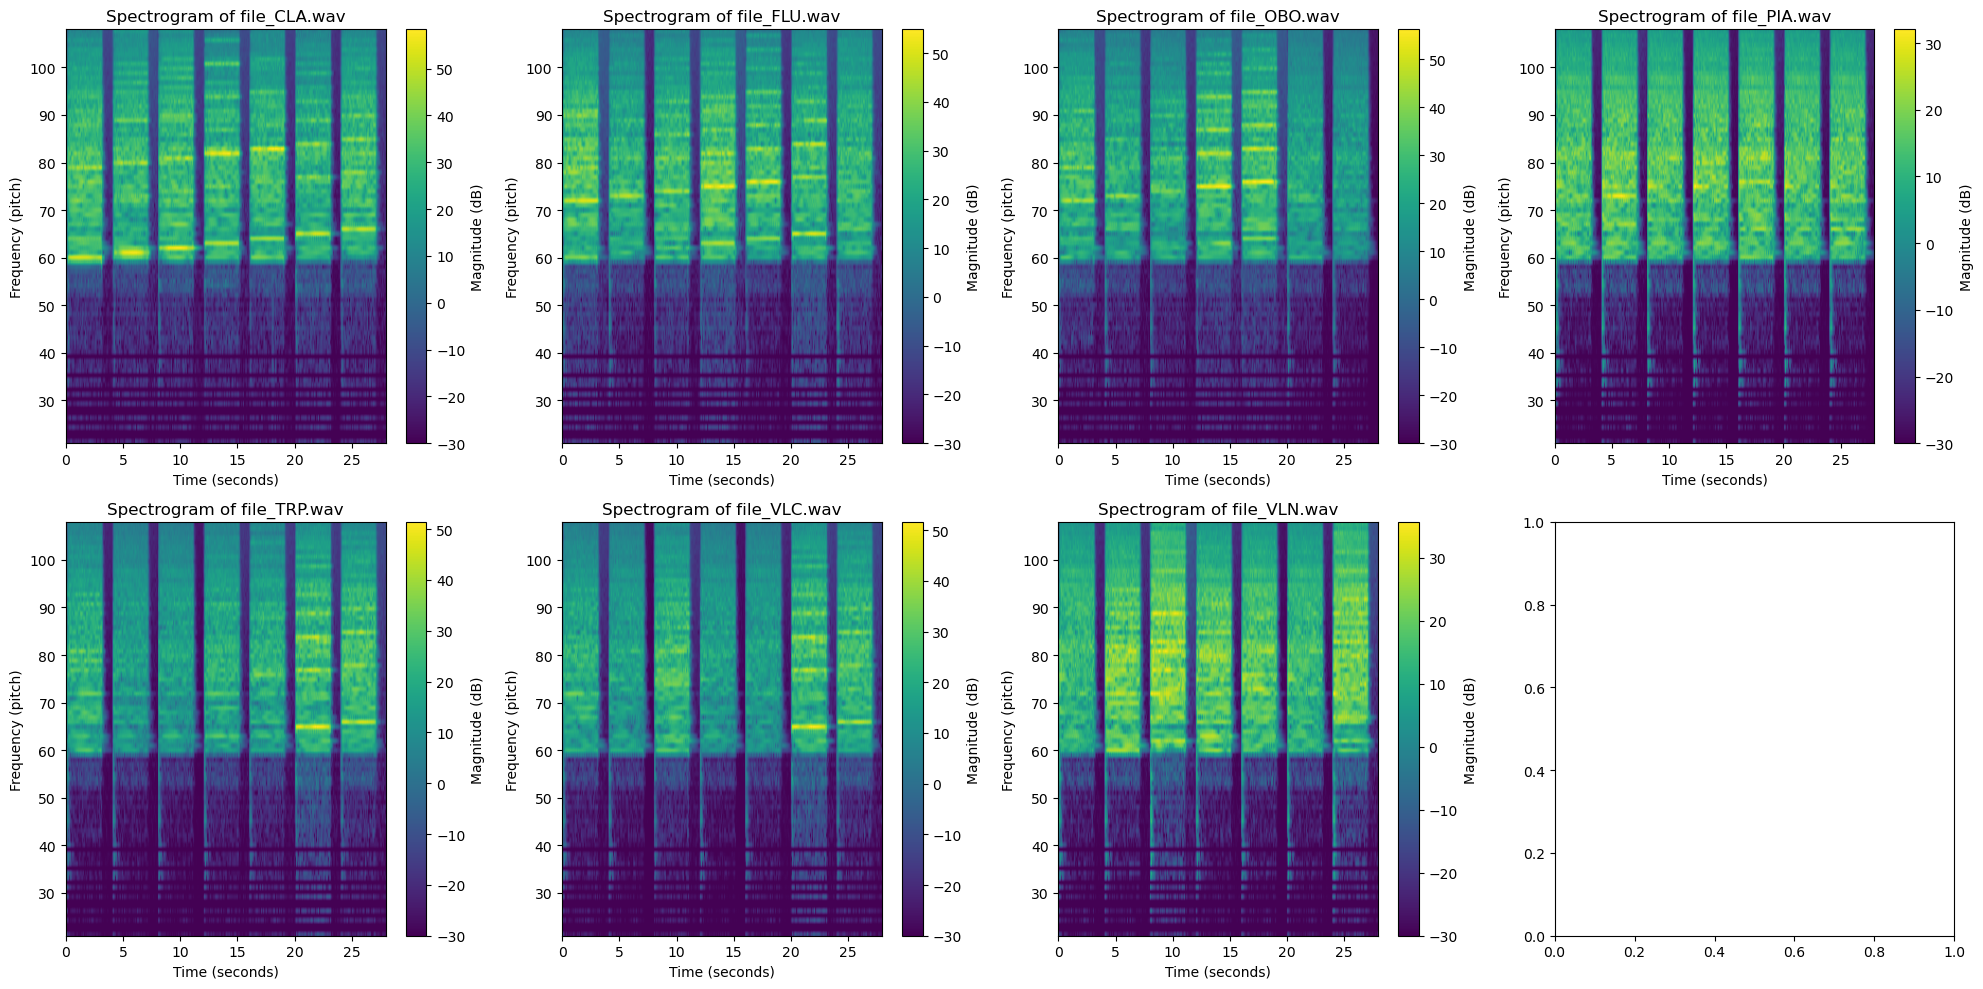

In [40]:
N = 4096
H = int(N / 2)
eps = np.finfo(float).eps


fig, axs = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows and 4 columns for 8 files
axs = axs.flatten()
for i, wav_file in enumerate(wav_files):
    x, sr = sf.read(wav_file)
    
    X = librosa.stft(x, n_fft=N, hop_length=H, window='hann', center=True, pad_mode="constant")
    
    T_coef = np.arange(X.shape[1]) * H / sr
    F_coef = np.arange(X.shape[0]) * sr / N
    
    Y = np.abs(X) ** 2
    
    Y_LF, F_coef_pitch = compute_spec_log_freq(Y, sr, N)
    
    img = axs[i].imshow(10* np.log10(Y_LF + 0.001) , origin='lower', aspect='auto', cmap='viridis',
                        extent=[T_coef[0], T_coef[-1], 0, 127])
    axs[i].set_title(f"Spectrogram of {os.path.basename((wav_file))}")
    axs[i].set_xlabel('Time (seconds)')
    axs[i].set_ylabel('Frequency (pitch)')
    axs[i].set_ylim([21, 108])
    
    cbar = fig.colorbar(img, ax=axs[i])
    cbar.set_label('Magnitude (dB)')

plt.tight_layout()
plt.show()

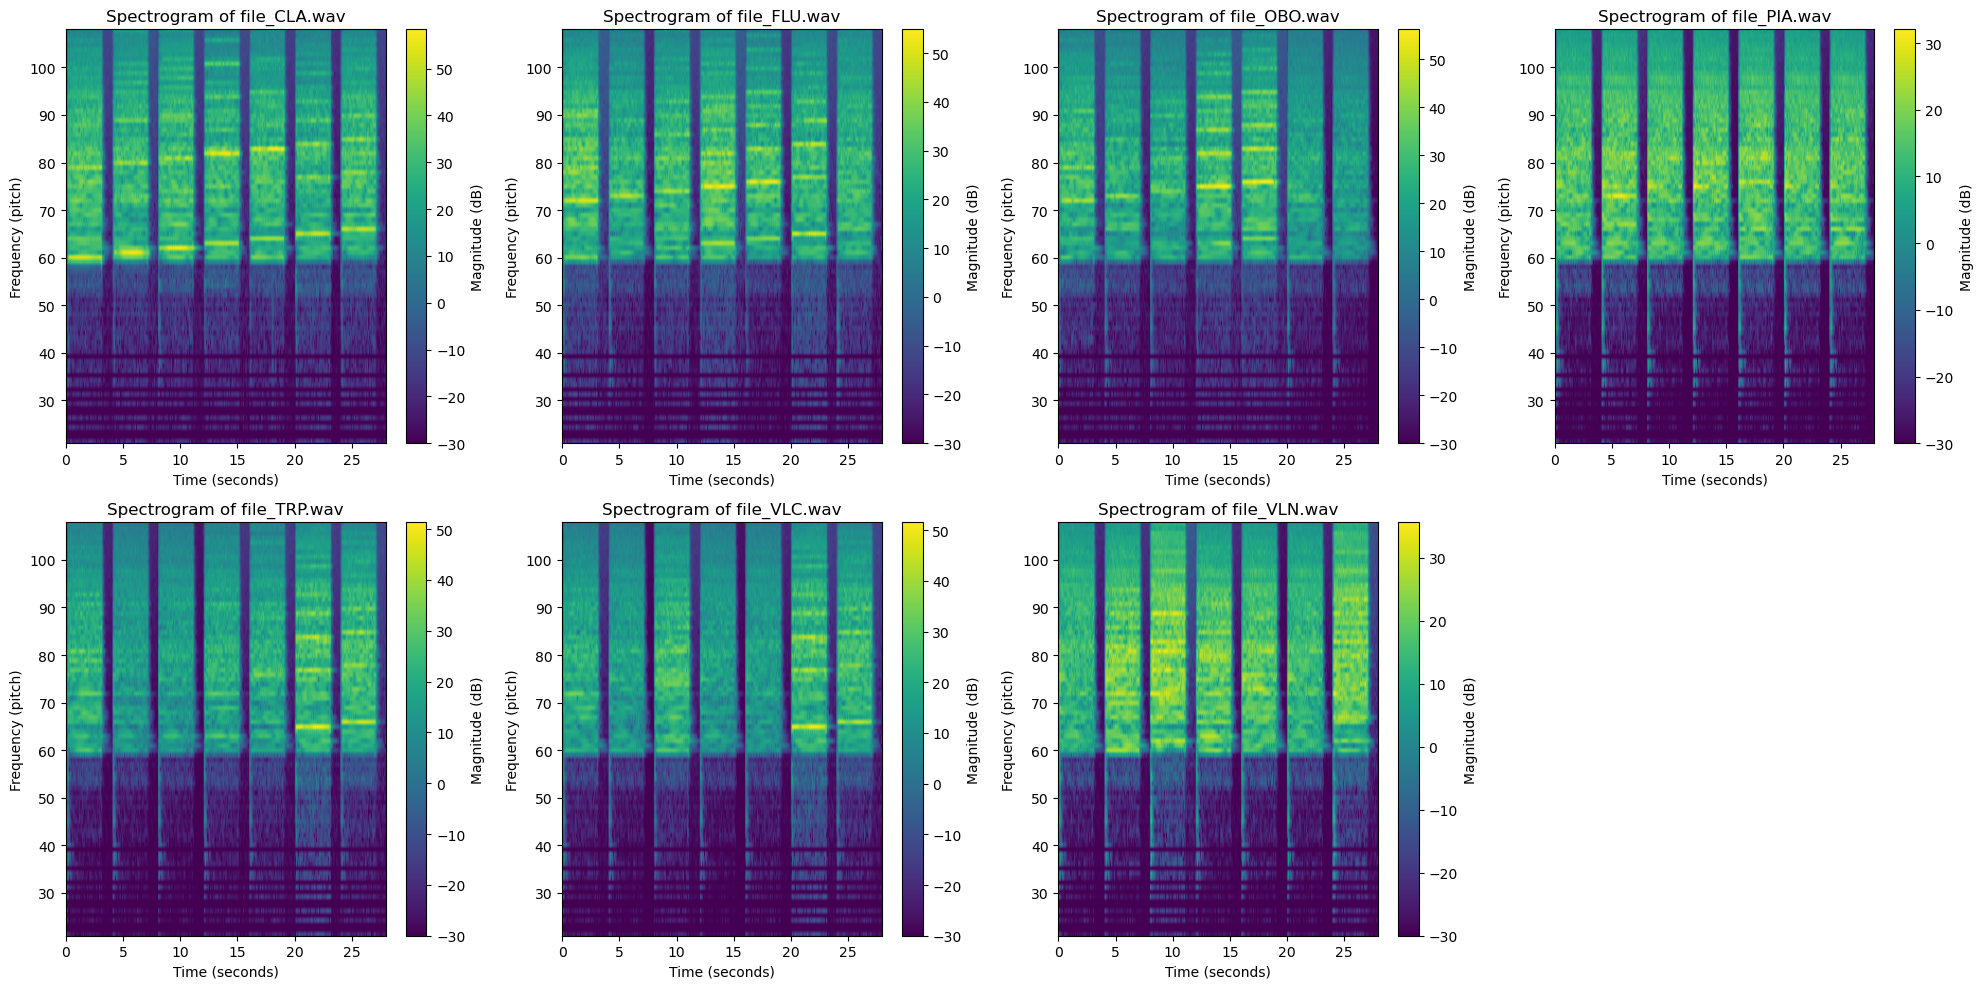

In [44]:
# Assuming wav_files is your list of audio files
N = 4096
H = int(N / 2)
eps = np.finfo(float).eps

# Number of plots based on the number of files
n_files = len(wav_files)

# Dynamically set the number of rows and columns based on the number of files
n_cols = 4  # You can adjust this value based on preference
n_rows = int(np.ceil(n_files / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))  # Adjust height based on number of rows
axs = axs.flatten()

for i, wav_file in enumerate(wav_files):
    x, sr = sf.read(wav_file)
    
    X = librosa.stft(x, n_fft=N, hop_length=H, window='hann', center=True, pad_mode="constant")
    
    T_coef = np.arange(X.shape[1]) * H / sr
    F_coef = np.arange(X.shape[0]) * sr / N
    
    Y = np.abs(X) ** 2
    
    # Assuming compute_spec_log_freq is a defined function
    Y_LF, F_coef_pitch = compute_spec_log_freq(Y, sr, N)
    
    img = axs[i].imshow(10 * np.log10(Y_LF + 0.001), origin='lower', aspect='auto', cmap='viridis',
                        extent=[T_coef[0], T_coef[-1], 0, 127])
    axs[i].set_title(f"Spectrogram of {os.path.basename(wav_file)}")
    axs[i].set_xlabel('Time (seconds)')
    axs[i].set_ylabel('Frequency (pitch)')
    axs[i].set_ylim([21, 108])
    
    cbar = fig.colorbar(img, ax=axs[i])
    cbar.set_label('Magnitude (dB)')

# Remove any empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.savefig("sndb.png") 
plt.show()